K Nearest neighbours
can be used for classification or regression tasks - and is also frequently used in missing value imputation
K is the number of neighbours

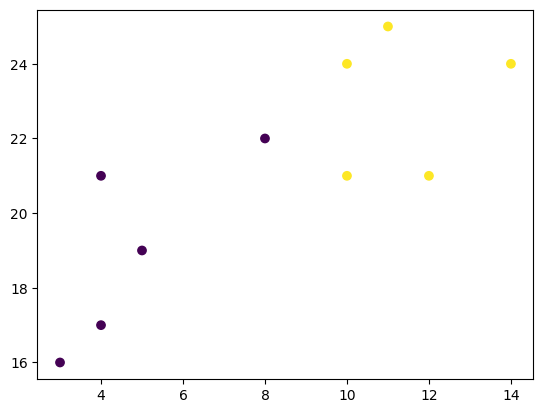

Indexes of 7 nearest neighbors: [[7 8 1 0 9 2 3]]
Classes of those neighbors: [0, 1, 0, 0, 1, 1, 0]


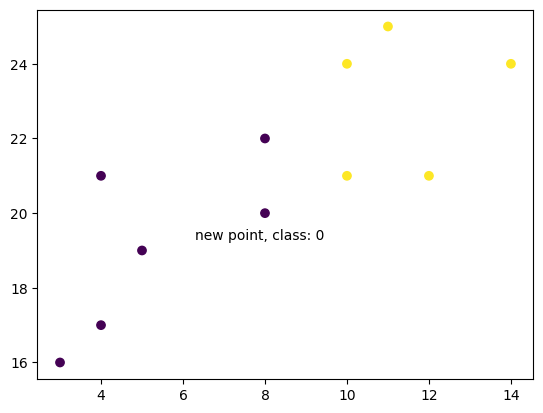

In [ ]:
#Larger values of K are often more robust to outliers and produce more stable decision boundaries than very small values
#using KNN for Classification
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14 , 8, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
classes = [0, 0, 1, 0, 0, 1, 1, 0, 1, 1]

plt.scatter(x, y, c=classes)
plt.show()


#taking K=1

from sklearn.neighbors import KNeighborsClassifier
data = list(zip(x,y)) #expected input : [(1, 4), (2, 5), (3, 6)]...
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(data,classes)

#classifying a new point
new_x=8
new_y=20

new_point=[(new_x,new_y)]
neighbors = knn.kneighbors(new_point, return_distance=False)
print("Indexes of 7 nearest neighbors:", neighbors)
print("Classes of those neighbors:", [classes[i] for i in neighbors[0]])

prediction=knn.predict(new_point)

plt.scatter(x+[new_x],y+[new_y],c=classes+[prediction[0]]) #add the new point
plt.text(x=new_x-1.7, y=new_y-0.7, s=f"new point, class: {prediction[0]}") #You're placing the text slightly to the left (-1.7) and slightly below (-0.7) the actual point (new_x, new_y).

plt.show()

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2  sentosa
1                4.9               3.0  ...               0.2  sentosa
2                4.7               3.2  ...               0.2  sentosa
3                4.6               3.1  ...               0.2  sentosa
4                5.0               3.6  ...               0.2  sentosa

[5 rows x 5 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


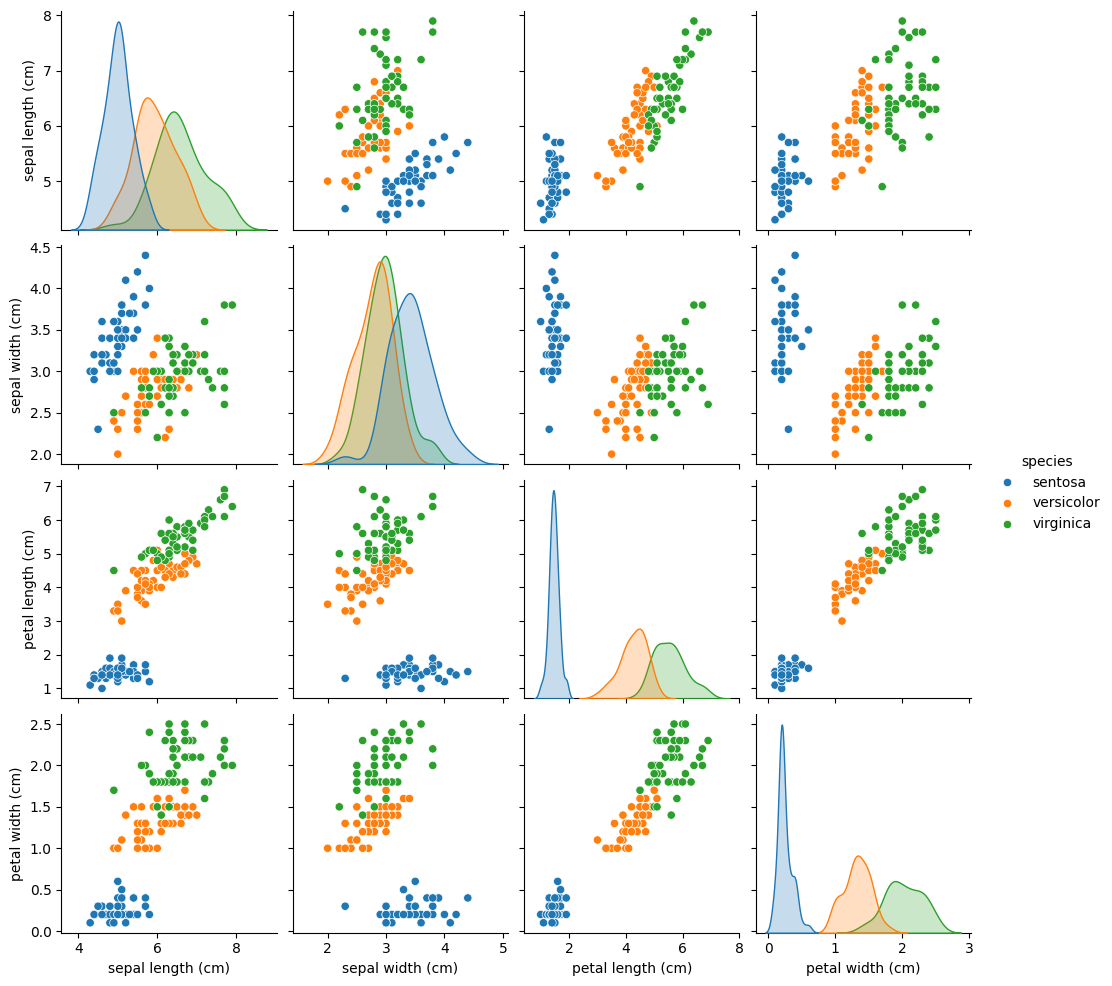

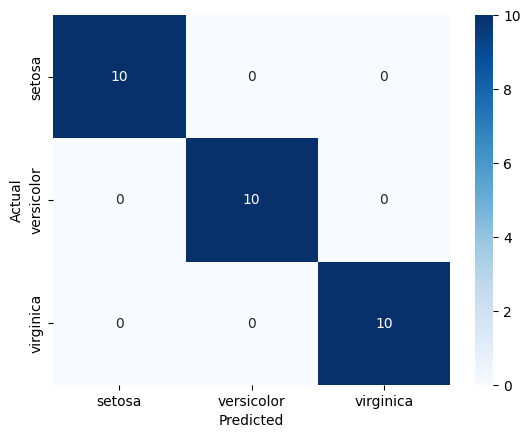

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



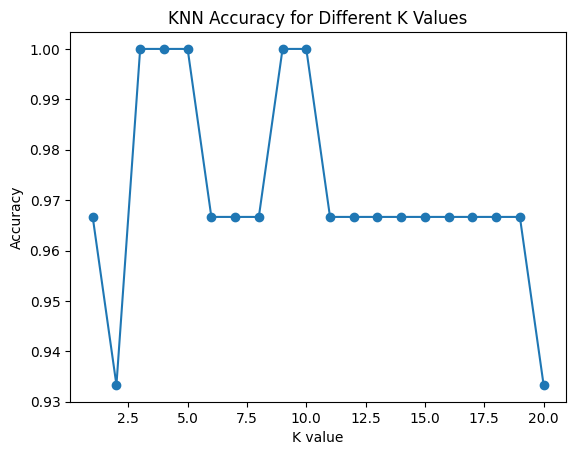

Scores for each fold: [0.93333333 1.         0.93333333 0.93333333 1.        ]
Average Accuracy: 0.96


In [ ]:
#project - classify species in the iris dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score

#loading iris dataset
iris= load_iris()

#convert to df (otherwise stored as a numoy array)
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

#map target values to names
df['species'] = df['species'].map({0:'sentosa',1:'versicolor',2:'virginica'})
print(df.head())

print(df.info())

#visualising relationships between features
sns.pairplot(df,hue='species')
plt.show()

#preparing the data
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) 
#stratify means if there is 30% sentosa in training set, same ratio(30%) will be in testing -> makes it more accurate

#training KNN Model
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

#make predictions
y_pred=knn.predict(X_test)

#Model evaluation
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues",xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#iris. target --> [0,1,2,1....]
#iris.target_names-->['sentosa',...] --> actual names

#classification report
print(classification_report(y_test,y_pred,target_names=iris.target_names))

#different k values
scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.plot(range(1, 21), scores, marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.show()

#cross validation for different splits (train-test)
scores = cross_val_score(knn, X, y, cv=5)  # cv=5 means split data into 5 folds

print("Scores for each fold:", scores)
print("Average Accuracy:", np.mean(scores))